# ⚡ Smart Energy Consumption Analysis

## Problem Statement
- "Electricity consumption in households or factories is higher than expected.
The goal is to identify peak usage hours, detect unnecessary energy wastage, and understand the reasons behind high electricity bills."

## Objective

- Analyze smart meter electricity data using Python
- Identify peak consumption hours
- Detect energy wastage patterns
- Provide data-driven recommendations for cost optimization
- Build an interactive Power BI dashboard to visualize insights

## Target Audience

- Factory / Industry Managers
- Electrical Maintenance Teams
- Energy Auditors
- Residential Society Management
- Business Owners who want to reduce electricity costs

### Libraries Import 

In [8]:
# Data handling 
import pandas as pd
import numpy as np

# Graphs 
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Warnings 
import warnings
warnings.filterwarnings('ignore')

In [9]:
# Graph style set 
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Data Load

In [10]:
# CSV file load 
df = pd.read_csv(r"C:\Users\vishal\Desktop\Dataset\energy_data.csv")

# DateTime column  proper format 
df['DateTime'] = pd.to_datetime(df['DateTime'])

print('📊 Dataset:', df.shape)  # rows x columns
print('\n📋 5 rows:')
df.head()

📊 Dataset: (8761, 11)

📋 5 rows:


,DateTime,Date,Hour,Month,Month_Name,Day_of_Week,Consumption_kWh,Voltage_V,Temperature_C,Zone,Cost_INR
0,2024-01-01 00:00:00,2024-01-01,0,1,January,Monday,0.50,224.6,13.3,Living Room,4.25
1,2024-01-01 01:00:00,2024-01-01,1,1,January,Monday,1.22,220.1,16.3,Living Room,10.37
2,2024-01-01 02:00:00,2024-01-01,2,1,January,Monday,1.14,232.4,18.4,Office,9.69
3,2024-01-01 03:00:00,2024-01-01,3,1,January,Monday,1.03,224.7,23.0,Kitchen,8.76
4,2024-01-01 04:00:00,2024-01-01,4,1,January,Monday,0.64,221.7,24.4,AC Unit,5.44


In [11]:
# Data related basic info
print('📌 Column names:', df.columns.tolist())
print('\n📌 Data types:')
print(df.dtypes)
print('\n📌 Missing values (null values):')
print(df.isnull().sum())

📌 Column names: ['DateTime', 'Date', 'Hour', 'Month', 'Month_Name', 'Day_of_Week', 'Consumption_kWh', 'Voltage_V', 'Temperature_C', 'Zone', 'Cost_INR']

📌 Data types:
DateTime           datetime64[ns]
Date                       object
Hour                        int64
Month                       int64
Month_Name                 object
Day_of_Week                object
Consumption_kWh           float64
Voltage_V                 float64
Temperature_C             float64
Zone                       object
Cost_INR                  float64
dtype: object

📌 Missing values (null values):
DateTime           0
Date               0
Hour               0
Month              0
Month_Name         0
Day_of_Week        0
Consumption_kWh    0
Voltage_V          0
Temperature_C      0
Zone               0
Cost_INR           0
dtype: int64


In [12]:
# Statistical summary - average, min, max 
print('📈 Statistical Summary:')
df[['Consumption_kWh', 'Voltage_V', 'Temperature_C', 'Cost_INR']].describe()

📈 Statistical Summary:


,Consumption_kWh,Voltage_V,Temperature_C,Cost_INR
count,8761.000000,8761.000000,8761.000000,8761.000000
mean,5.123802,230.085675,24.350337,43.552290
std,3.225439,6.909262,8.740662,27.416276
min,0.500000,218.000000,10.000000,4.250000
25%,2.490000,224.200000,17.500000,21.170000
50%,4.240000,230.100000,23.100000,36.040000
75%,7.990000,236.100000,31.200000,67.920000
max,13.610000,242.000000,42.000000,115.690000


# Hourly Analysis(for whitch time more enrgy used)

🔴 Peak Hour: 19:00 has the highest electricity consumption!


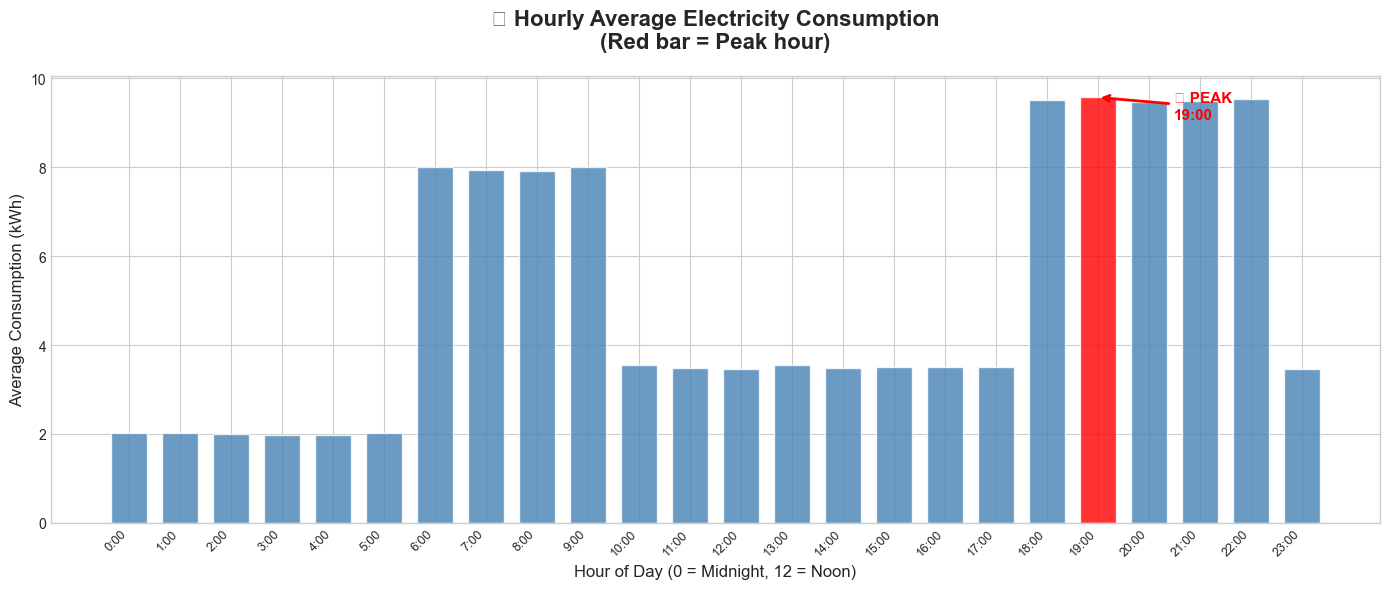

✅ Graph saved successfully!


In [17]:
# Calculate average consumption by Hour
hourly_avg = df.groupby('Hour')['Consumption_kWh'].mean().reset_index()
hourly_avg.columns = ['Hour', 'Avg_Consumption']

# Find the Peak hour
peak_hour = hourly_avg.loc[hourly_avg['Avg_Consumption'].idxmax(), 'Hour']
print(f'🔴 Peak Hour: {peak_hour}:00 has the highest electricity consumption!')

# Create the Graph
fig, ax = plt.subplots(figsize=(14, 6))

colors = ['red' if h == peak_hour else 'steelblue' for h in hourly_avg['Hour']]
bars = ax.bar(hourly_avg['Hour'], hourly_avg['Avg_Consumption'],
              color=colors, alpha=0.8, edgecolor='white', width=0.7)

ax.set_title('⚡ Hourly Average Electricity Consumption\n(Red bar = Peak hour)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Hour of Day (0 = Midnight, 12 = Noon)', fontsize=12)
ax.set_ylabel('Average Consumption (kWh)', fontsize=12)
ax.set_xticks(range(24))
ax.set_xticklabels([f'{h}:00' for h in range(24)],
                   rotation=45, ha='right', fontsize=9)

# Peak hour label
ax.annotate(f'🔴 PEAK\n{peak_hour}:00', 
            xy=(peak_hour,
                hourly_avg.loc[hourly_avg['Hour'] == peak_hour,
                               'Avg_Consumption'].values[0]),
            xytext=(peak_hour + 1.5,
                    hourly_avg['Avg_Consumption'].max() * 0.95),
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            fontsize=11, color='red', fontweight='bold')

plt.tight_layout()
plt.savefig('hourly_consumption.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Graph saved successfully!')

# Monthly Analysis (In which month does the electricity bill come highest?)

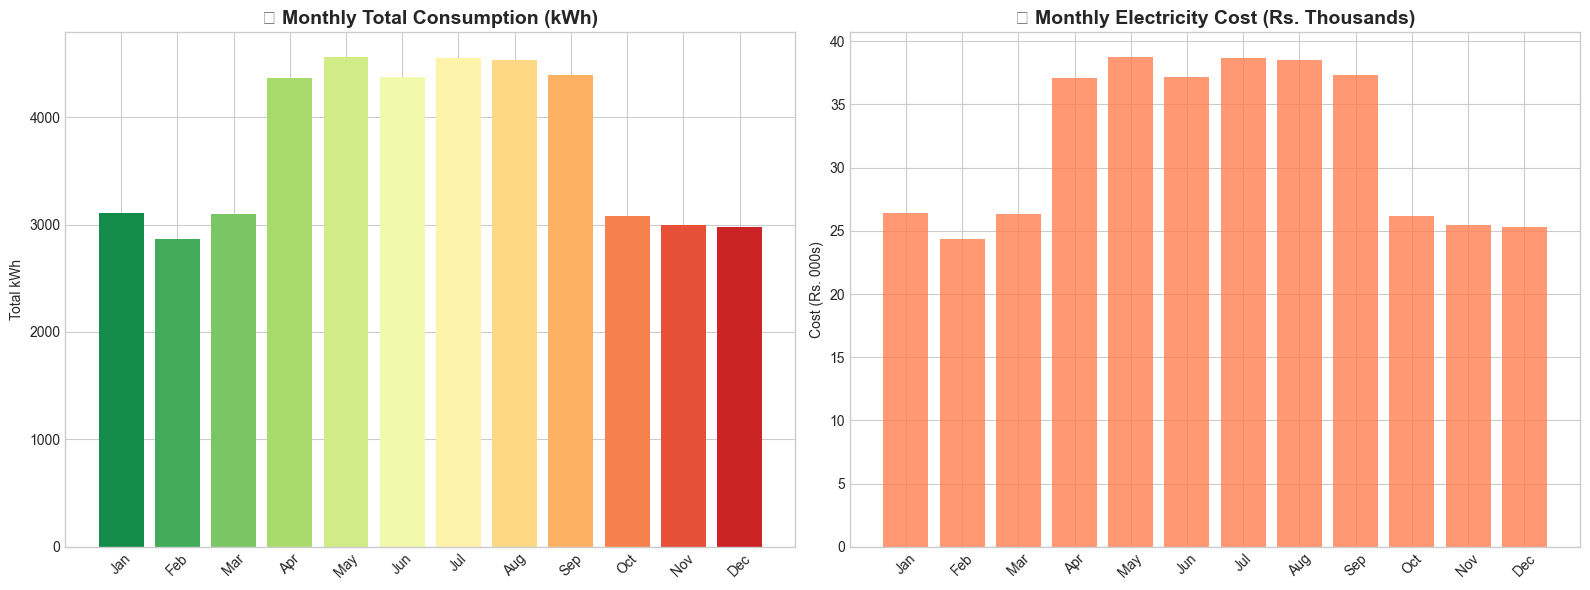

💸 Months with the highest electricity bills:
Month_Name  Total_kWh  Total_Cost
       May    4561.59    38773.54
      July    4550.12    38675.97
    August    4530.32    38507.65


In [18]:
# Total consumption by Month
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly = df.groupby('Month_Name').agg(
    Total_kWh=('Consumption_kWh', 'sum'),
    Total_Cost=('Cost_INR', 'sum'),
    Avg_Temp=('Temperature_C', 'mean')
).reindex(month_order).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Monthly consumption
axes[0].bar(range(12), monthly['Total_kWh'],
            color=sns.color_palette('RdYlGn_r', 12))
axes[0].set_title('📅 Monthly Total Consumption (kWh)',
                  fontsize=14, fontweight='bold')
axes[0].set_xticks(range(12))
axes[0].set_xticklabels([m[:3] for m in month_order], rotation=45)
axes[0].set_ylabel('Total kWh')

# Plot 2: Monthly cost
axes[1].bar(range(12), monthly['Total_Cost'] / 1000,
            color='coral', alpha=0.8)
axes[1].set_title('💰 Monthly Electricity Cost (Rs. Thousands)',
                  fontsize=14, fontweight='bold')
axes[1].set_xticks(range(12))
axes[1].set_xticklabels([m[:3] for m in month_order], rotation=45)
axes[1].set_ylabel('Cost (Rs. 000s)')

plt.tight_layout()
plt.savefig('monthly_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Top expensive months
print('💸 Months with the highest electricity bills:')
print(
    monthly[['Month_Name', 'Total_kWh', 'Total_Cost']]
    .sort_values('Total_Cost', ascending=False)
    .head(3)
    .to_string(index=False)
)

# Zone Analysis(Where is electricity getting wasted?)

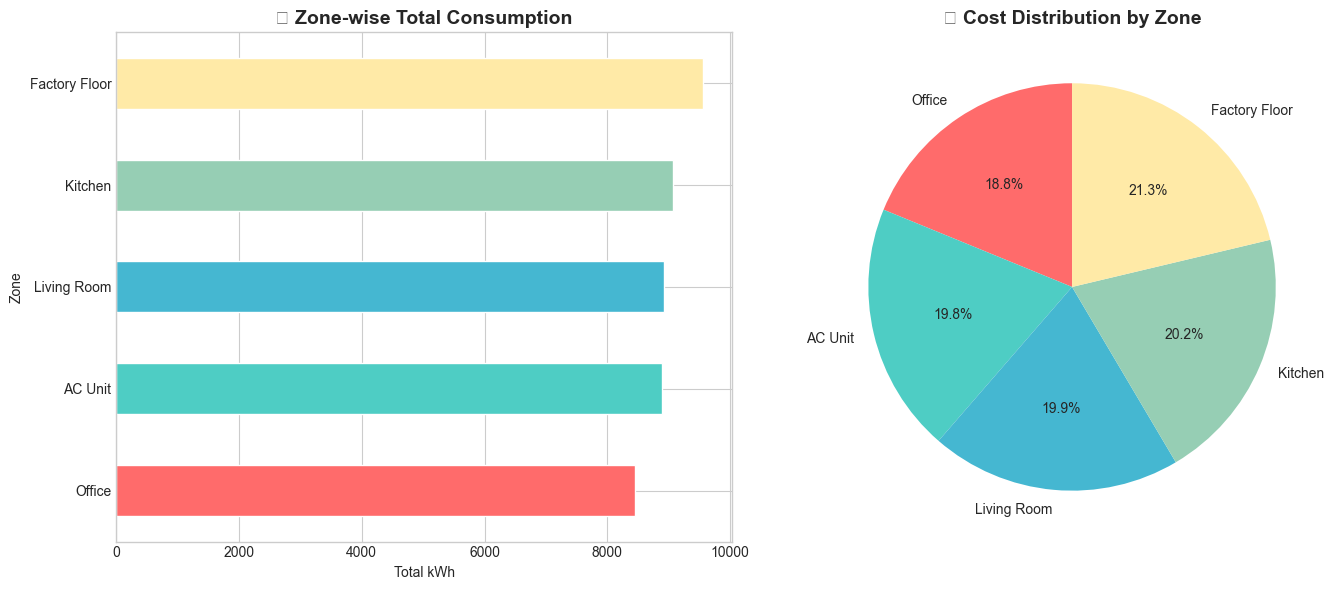


📊 Zone Summary:
               Total_kWh   Avg_kWh  Total_Cost
Zone                                          
Office           8443.14  4.931741    71766.56
AC Unit          8896.65  5.169465    75621.52
Living Room      8922.43  5.154495    75840.75
Kitchen          9075.14  5.162196    77138.64
Factory Floor    9552.27  5.194274    81194.14


In [19]:
# Zone-wise analysis
zone_analysis = df.groupby('Zone').agg(
    Total_kWh=('Consumption_kWh', 'sum'),
    Avg_kWh=('Consumption_kWh', 'mean'),
    Total_Cost=('Cost_INR', 'sum')
).sort_values('Total_kWh', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Horizontal bar chart
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
zone_analysis['Total_kWh'].plot(
    kind='barh',
    ax=axes[0],
    color=colors,
    edgecolor='white'
)

axes[0].set_title('🏠 Zone-wise Total Consumption',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Total kWh')

# Pie chart
zone_analysis['Total_Cost'].plot(
    kind='pie',
    ax=axes[1],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    fontsize=10
)

axes[1].set_title('💰 Cost Distribution by Zone',
                  fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('zone_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 Zone Summary:')
print(zone_analysis.to_string())

# Wastage Detection(In which area/place is more electricity being consumed?)

🌙 Night Hours (12am–5am) Analysis:
   Normal usage records: 1199
   ⚠️ High usage records (WASTAGE): 992
   Total wasted kWh: 3082.66 kWh
   💸 Wasted money: Rs. 26202.47

📊 Creating Heatmap...


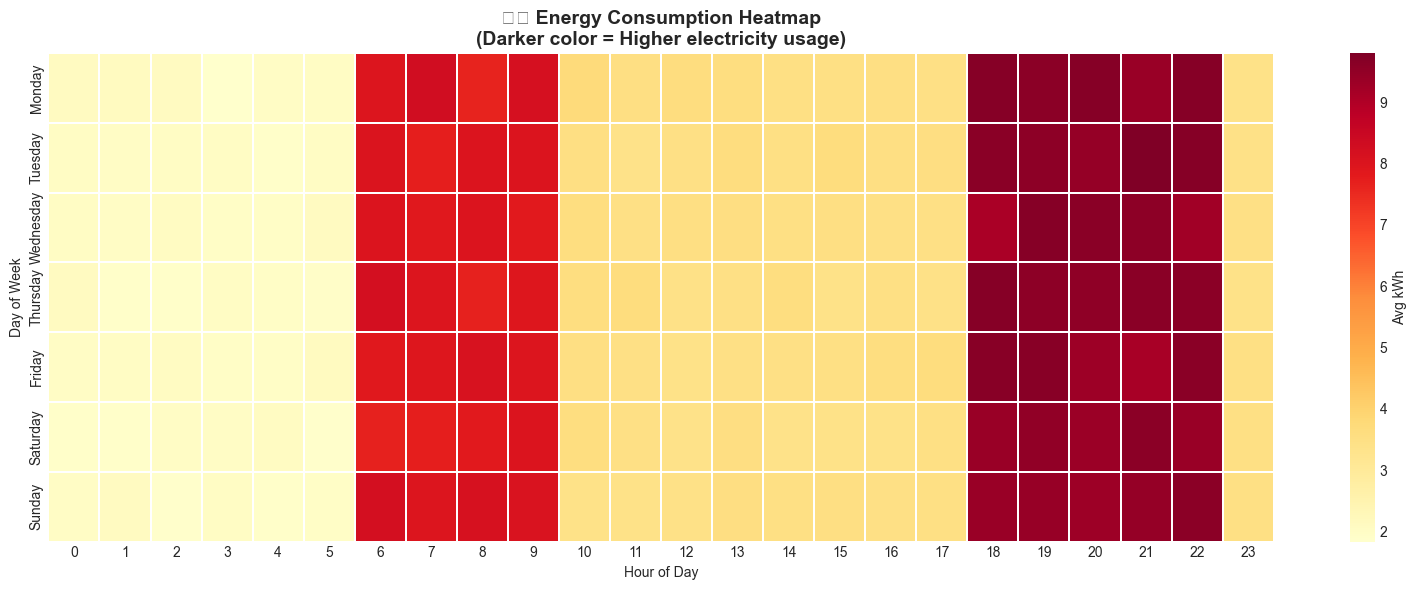

In [20]:
# High consumption between 12 AM to 5 AM = Wastage!
night_waste = df[(df['Hour'] >= 0) & (df['Hour'] <= 5)]

normal_night = night_waste[night_waste['Consumption_kWh'] <= 2.0]
waste = night_waste[night_waste['Consumption_kWh'] > 2.0]

print(f'🌙 Night Hours (12am–5am) Analysis:')
print(f'   Normal usage records: {len(normal_night)}')
print(f'   ⚠️ High usage records (WASTAGE): {len(waste)}')
print(f'   Total wasted kWh: {waste["Consumption_kWh"].sum():.2f} kWh')
print(f'   💸 Wasted money: Rs. {waste["Cost_INR"].sum():.2f}')

# Heatmap – Day vs Hour consumption
print('\n📊 Creating Heatmap...')

day_hour = df.groupby(['Day_of_Week', 'Hour'])['Consumption_kWh'].mean().unstack()

# Fix day order
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_hour = day_hour.reindex(day_order)

fig, ax = plt.subplots(figsize=(16, 6))

sns.heatmap(
    day_hour,
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.3,
    cbar_kws={'label': 'Avg kWh'}
)

ax.set_title(
    '🗓️ Energy Consumption Heatmap\n(Darker color = Higher electricity usage)',
    fontsize=14,
    fontweight='bold'
)

ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')

plt.tight_layout()
plt.savefig('heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Final Summary & Recommendations

In [21]:
print('=' * 55)
print('⚡ SMART ENERGY ANALYSIS - FINAL REPORT')
print('=' * 55)

print(f'\n📊 Total Records Analyzed: {len(df):,}')
print(f'📅 Period: {df["Date"].min()} to {df["Date"].max()}')

print(f'\n🔴 Peak Hour: {peak_hour}:00')
print(f'📈 Average Consumption: {df["Consumption_kWh"].mean():.2f} kWh/hour')
print(f'💰 Total Annual Cost: Rs. {df["Cost_INR"].sum():,.0f}')
print(f'⚠️ Wasted Cost (Night): Rs. {waste["Cost_INR"].sum():,.0f}')

peak_month = monthly.loc[monthly['Total_kWh'].idxmax(), 'Month_Name']
print(f'🌡️ Peak Month: {peak_month} (Summer - AC Usage)')

top_zone = zone_analysis['Total_kWh'].idxmax()
print(f'🏠 Highest Consuming Zone: {top_zone}')

print('\n✅ RECOMMENDATIONS:')
print(f'   1. Avoid using heavy appliances after {peak_hour}:00')
print(f'   2. Turn off unused devices at night (Save Rs. {round(waste["Cost_INR"].sum())})')
print('   3. During summer months, keep AC temperature at 24°C')
print(f'   4. Use energy-efficient appliances in {top_zone}')

print('\n✅ Analysis Complete! Provide this CSV to Power BI.')

⚡ SMART ENERGY ANALYSIS - FINAL REPORT

📊 Total Records Analyzed: 8,761
📅 Period: 2024-01-01 to 2024-12-31

🔴 Peak Hour: 19:00
📈 Average Consumption: 5.12 kWh/hour
💰 Total Annual Cost: Rs. 381,562
⚠️ Wasted Cost (Night): Rs. 26,202
🌡️ Peak Month: May (Summer - AC Usage)
🏠 Highest Consuming Zone: Factory Floor

✅ RECOMMENDATIONS:
   1. Avoid using heavy appliances after 19:00
   2. Turn off unused devices at night (Save Rs. 26202)
   3. During summer months, keep AC temperature at 24°C
   4. Use energy-efficient appliances in Factory Floor

✅ Analysis Complete! Provide this CSV to Power BI.
